In [99]:
import numpy as np
import matplotlib.pyplot as plt

# 1 Transition matrix and basic checks

#### 1.1 is fulfilled

In [100]:
P1 = np.array(
    [[0.5, 0.2, 0.3], 
    [0.025, 0.9125, 0.0625], 
    [0.3, 0.5, 0.2]]
)

pi = np.array([0.1, 0.8, 0.1])

# Verify if it satisfies the stationary condition: pi @ P1 == pi
is_stationary = np.allclose(pi @ P1, pi)

print("Is it a valid stationary distribution?", is_stationary)
print("Calculated pi * P1:", pi @ P1)
print("Original pi:        ", pi)

len(P1)

Is it a valid stationary distribution? True
Calculated pi * P1: [0.1 0.8 0.1]
Original pi:         [0.1 0.8 0.1]


3

# OOP Implementation


In [101]:
class Node():
    def __init__(self, state):
        self.state = state
        self.probs = P1[state]
        if any(p < 0 for p in self.probs):
            raise ValueError(f"Probabilities in node {state} cannot be negative.")
        if not np.isclose(sum(self.probs), 1.0):
            raise ValueError(f"Probabilities in node {state} must sum to 1 (got {sum(self.probs)}).")

    def nextState(self, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        states = np.arange(len(self.probs))
        return rng.choice(states, p=self.probs)

In [102]:
class MarkovChain():
    def __init__(self, P1):
        self.P1 = P1
        self.validateTransitionMatrix(self.P1)

    def validateTransitionMatrix(self, P1):
        for i in range(len(self.P1)):
            if not np.isclose(sum(P1[i]), 1):
                print(sum(P1[i]))
                raise ValueError(f"Row {i} does not sum to 1")
            for j in range(len(self.P1)):
                if P1[i][j] < 0:
                    raise ValueError(f"Entry {i},{j} is negative")

    def populationVecPropagator(self, initPopVec):
        return initPopVec @ self.P1

    def trajectory(self, start_state, steps, rng=None):
        if rng is None:
            rng = np.random.default_rng()

        current_state = start_state
        path = [current_state]

        for _ in range(steps):
            node = Node(state=current_state)
            current_state = node.nextState(rng=rng)
            path.append(current_state)

        return path

    def plot(self, states_data, title="State Distribution"):
        """Plots a clean discrete histogram for any number of states."""
        fig, ax = plt.subplots(figsize=(6, 4))

        # Dynamically set bin edges based on the size of the transition matrix P
        num_states = len(self.P)
        bin_edges = np.arange(-0.5, num_states + 0.5, 1)

        ax.hist(
            states_data,
            bins=bin_edges,
            rwidth=0.8,
            density=True,
            alpha=0.7,
            color="skyblue",
            edgecolor="black",
        )

        ax.set_xticks(range(num_states))
        ax.set_xlabel("State")
        ax.set_ylabel("Proportion")
        ax.set_title(title)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

[0, np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(1)]


AttributeError: 'MarkovChain' object has no attribute 'P'

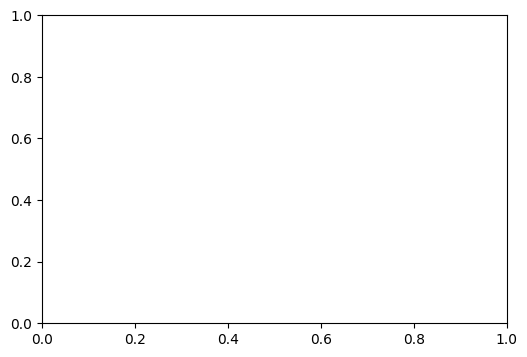

In [105]:
trajec1 = MarkovChain(P1=P1)

rng = np.random.default_rng(seed=823479847)
my_path = trajec1.trajectory(start_state=0, steps=10, rng=rng)
print(my_path)
trajec1.plot(states_data=my_path)